# CardioIA — Parte 2: classificação de risco em textos

**Grupo AI4Success — 2TIAOR**  
Durval de Oliveira Dorta Junior (RM 567007) e Guilherme da Nobrega Gontijo (RM 562211).

Este notebook atende à Parte 2 do enunciado: carregar frases rotuladas, aplicar **TF-IDF**, treinar um classificador simples e avaliar acurácia, comportamento e distorções. Base de 60 frases didáticas (30 por classe), sem dados reais de pacientes. Não é um sistema validado de triagem.

Execute todas as células em ordem com o ambiente do projeto. Funciona com o diretório de trabalho na raiz ou em `src/parte2/`. Dependências: `python -m pip install -r requirements.txt` na raiz.

**Fundamentação:** capítulo 11, seções 3.3 e 4.2 (vetorização e classificação); capítulo 07, seção 2 e seções 8.3–8.4 (vieses), conforme [mapeamento das apostilas](../../document/MAPEAMENTO_APOSTILAS_FASE2.md). Os PDFs são materiais locais de estudo.

## 1. Dados, autoria e rastreabilidade

As fontes institucionais contextualizam cenários, mas não forneceram os pares frase/rótulo. P01–P30 tiveram aprovação do responsável; P31–P60 foram elaboradas pelo assistente sob autorização para concluir sem revisão individual. Veja [fontes](FONTES_DATASET.md) e [curadoria](RELATORIO_CURADORIA.md). A base inicial de 12 frases está arquivada e não participa deste treino.

O CSV tem apenas `frase,situacao`. Proveniência e grupos servem para auditoria/divisão e **não entram no modelo**.

In [1]:
from pathlib import Path
import sys
import json
import platform
from importlib.metadata import version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.metrics import ConfusionMatrixDisplay

candidatas = [Path.cwd(), Path.cwd() / 'src' / 'parte2']
BASE = next((p for p in candidatas if (p / 'protocolo_avaliacao.json').exists()), None)
if BASE is None:
    raise FileNotFoundError('Abra o notebook com o diretório na raiz do projeto ou em src/parte2/.')
sys.path.insert(0, str(BASE))
from classificador_risco import carregar_dados, criar_modelo, avaliar, exportar, CLASSES
print('Python:', platform.python_version())
display(pd.DataFrame({'pacote': ['pandas', 'numpy', 'scikit-learn'],
                      'versão': [version(p) for p in ['pandas', 'numpy', 'scikit-learn']]}))

Python: 3.12.10


,pacote,versão
0,pandas,3.0.5
1,numpy,2.5.3
2,scikit-learn,1.9.1


In [2]:
dados = carregar_dados(BASE)
display(dados[['id','frase','situacao','referencias','status_revisao']].head(10))
display(dados['situacao'].value_counts().rename('quantidade').to_frame())
print('60 registros, textos/rótulos compatíveis com a proveniência e hashes conferidos.')

,id,frase,situacao,referencias,status_revisao
0,P01,sinto dor no peito e falta de ar,alto risco,E1;R1,aprovado pelo responsável pelo projeto
1,P02,"Desde esta manhã, sinto pressão no tórax acomp...",alto risco,R1,aprovado pelo responsável pelo projeto
2,P03,A dor começou no peito e agora também sinto do...,alto risco,R1,aprovado pelo responsável pelo projeto
3,P04,Meu coração está disparado e estou com dificul...,alto risco,R2,aprovado pelo responsável pelo projeto
4,P05,"Não sinto dor no braço, mas estou com aperto n...",alto risco,R1,aprovado pelo responsável pelo projeto
5,P06,Tive um pequeno incômodo na região lombar depo...,baixo risco,E1;R3,aprovado pelo responsável pelo projeto
6,P07,Meu punho ficou dolorido após uma pequena torç...,baixo risco,R4,aprovado pelo responsável pelo projeto
7,P08,Sinto um incômodo discreto na musculatura das ...,baixo risco,R3,aprovado pelo responsável pelo projeto
8,P09,"Hoje me sinto bem, respiro normalmente e reali...",baixo risco,criterio_interno,aprovado pelo responsável pelo projeto
9,P10,Não tenho dor no peito nem falta de ar e estou...,baixo risco,criterio_interno,aprovado pelo responsável pelo projeto


,quantidade
situacao,
alto risco,30
baixo risco,30


60 registros, textos/rótulos compatíveis com a proveniência e hashes conferidos.


## 2. Treino e teste por grupos de cenários

A divisão foi registrada **antes de treinar**, em [protocolo](PROTOCOLO_AVALIACAO.md) e `divisao_avaliacao.csv`. Não escolhemos sementes, grupos ou parâmetros pelos resultados.

Os grupos G01 (respiração/suor) e G02 (bem-estar) formam o teste: 19 frases. Os outros quatro grupos formam o treino: 41 frases. Famílias próximas foram reunidas para evitar que trocar o local ou a redação crie uma falsa independência.

O teste contém cenários retidos, sobretudo bem-estar sem exemplos de treino. Não equivale a uma amostra clínica aleatória. Há vocabulário compartilhado entre cenários torácicos de treino e teste; o agrupamento reduz vazamento evidente, sem eliminar todas as dependências.

In [3]:
treino = dados[dados['conjunto'] == 'treino'].copy()
teste = dados[dados['conjunto'] == 'teste'].copy()
assert set(treino.grupo_avaliacao).isdisjoint(teste.grupo_avaliacao)
assert set(treino.familia_cenario).isdisjoint(teste.familia_cenario)
assert set(treino.id).isdisjoint(teste.id)
display(pd.crosstab(dados['conjunto'], dados['situacao']))
display(pd.crosstab(dados['grupo_avaliacao'], dados['conjunto']))
print('IDs de treino:', ', '.join(treino.id))
print('IDs de teste:', ', '.join(teste.id))

situacao,alto risco,baixo risco
conjunto,,
teste,12,7
treino,18,23


conjunto,teste,treino
grupo_avaliacao,,
G01_respiratorio_suor,12,0
G02_bem_estar,7,0
G03_toracico_irradiacao_tontura,0,9
G04_esforco_muscular_melhora,0,16
G05_lesoes_membros,0,12
G06_costas_alerta,0,4


IDs de treino: P03, P06, P07, P08, P11, P12, P15, P16, P17, P18, P19, P22, P25, P26, P27, P28, P29, P31, P33, P34, P35, P36, P37, P38, P39, P42, P43, P44, P45, P46, P47, P48, P49, P51, P53, P54, P55, P56, P57, P58, P59
IDs de teste: P01, P02, P04, P05, P09, P10, P13, P14, P20, P21, P23, P24, P30, P32, P40, P41, P50, P52, P60


## 3. TF-IDF e regressão logística

TF-IDF combina frequência de termos com um peso que reduz a influência dos termos muito comuns. O vocabulário e os pesos IDF são aprendidos **somente no treino**. Usamos unigramas e bigramas para representar palavras e pares, normalização de caixa/acentos e nenhuma remoção de stopwords, preservando “não” e “sem”. Isso não garante compreensão de negações.

A regressão logística é um classificador linear simples permitido pelo enunciado. Parâmetros fixados: C=1, solver lbfgs, max_iter=1000 e random_state=42. `Pipeline` mantém vetorização e classificador juntos. A construção está no módulo local `classificador_risco.py`, compartilhado pelo notebook e execução de terminal; o ajuste e a avaliação são executados abaixo.

In [4]:
modelo = criar_modelo()
display(modelo)
modelo.fit(treino['frase'], treino['situacao'])
tfidf = modelo.named_steps['tfidf']
X_treino = tfidf.transform(treino['frase'])
X_teste = tfidf.transform(teste['frase'])
print('Matriz de treino:', X_treino.shape, '| Matriz de teste:', X_teste.shape)
print('Termos no vocabulário:', len(tfidf.vocabulary_))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",'unicode'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None


Matriz de treino: (41, 679) | Matriz de teste: (19, 679)
Termos no vocabulário: 679


In [5]:
# Recorte didático: cinco frases e doze termos com maior soma de TF-IDF no treino.
termos = tfidf.get_feature_names_out()
colunas = np.asarray(X_treino.sum(axis=0)).ravel().argsort()[-12:][::-1]
display(treino[['id','frase']].head())
display(pd.DataFrame(X_treino[:5, colunas].toarray(),
                     index=treino.id.iloc[:5], columns=termos[colunas]).round(3))

,id,frase
2,P03,A dor começou no peito e agora também sinto do...
5,P06,Tive um pequeno incômodo na região lombar depo...
6,P07,Meu punho ficou dolorido após uma pequena torç...
7,P08,Sinto um incômodo discreto na musculatura das ...
10,P11,Estou com um peso no peito há meia hora e a do...


,dor,no,de,esta,um,depois,peito,no peito,sinto,que,uma,com
id,,,,,,,,,,,,
P03,0.216,0.266,0.000,0.000,0.000,0.000,0.148,0.148,0.148,0.000,0.000,0.000
P06,0.000,0.000,0.098,0.089,0.095,0.095,0.000,0.000,0.000,0.000,0.000,0.000
P07,0.089,0.000,0.000,0.097,0.000,0.000,0.000,0.000,0.000,0.000,0.118,0.000
P08,0.000,0.000,0.000,0.000,0.086,0.000,0.000,0.000,0.101,0.098,0.098,0.000
P11,0.087,0.108,0.000,0.000,0.101,0.000,0.119,0.119,0.000,0.000,0.000,0.119


## 4. Avaliação do conjunto retido

**Acurácia** é a fração de acertos. **Precisão** mede quantos dos exemplos previstos numa classe pertencem a ela; **recall** mede quantos dos exemplos dessa classe foram reconhecidos; **F1** combina precisão e recall. O baseline prevê sempre a classe mais frequente do treino, sem interpretar frases.

Considerando alto risco como positivo, um **falso negativo** é um alto previsto como baixo e um **falso positivo** é um baixo previsto como alto. Os rótulos de referência são didáticos, não diagnósticos reais. Usamos zero_division=0 para métricas indefinidas quando uma classe não é prevista.

,modelo,acurácia
0,TF-IDF + regressão logística,0.894737
1,Classe mais frequente do treino,0.368421


,precision,recall,f1-score,support
alto risco,1.000,0.833,0.909,12.000
baixo risco,0.778,1.000,0.875,7.000
accuracy,0.895,0.895,0.895,0.895
macro avg,0.889,0.917,0.892,19.000
weighted avg,0.918,0.895,0.897,19.000


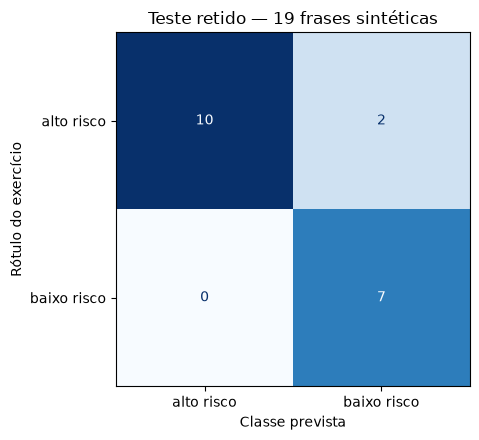

In [6]:
resultado, previsoes = avaliar(modelo, treino, teste)
display(pd.DataFrame([
    {'modelo': 'TF-IDF + regressão logística', 'acurácia': resultado['acuracia']},
    {'modelo': 'Classe mais frequente do treino', 'acurácia': resultado['acuracia_baseline']},
]))
display(pd.DataFrame(resultado['relatorio']).T.round(3))
cm = np.array(resultado['matriz_confusao'])
fig, ax = plt.subplots(figsize=(5.8, 4.5))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set(xlabel='Classe prevista', ylabel='Rótulo do exercício', title='Teste retido — 19 frases sintéticas')
fig.tight_layout()
plt.show()

## 5. Erros e diferenças entre cenários

A tabela permite auditar cada previsão. Um erro não será usado para alterar a divisão ou ajustar o modelo nesta entrega; isso tornaria o teste parte do desenvolvimento. O desempenho por grupo ajuda a distinguir reconhecimento de sinais de alerta de transferência para relatos de bem-estar.

In [7]:
display(previsoes)
erros = previsoes[~previsoes['acerto']]
print('Erros:', len(erros))
display(erros[['id','frase','situacao','previsto']])
display(previsoes.groupby('grupo_avaliacao').agg(exemplos=('id','size'), acuracia=('acerto','mean')))
fn = int(cm[0,1]); fp = int(cm[1,0])
display(Markdown(f'No teste houve **{fn} alto(s) previstos como baixo** e **{fp} baixo(s) previstos como alto**. '
                 'Essas contagens descrevem somente este conjunto sintético.'))

,id,grupo_avaliacao,frase,situacao,previsto,acerto
0,P01,G01_respiratorio_suor,sinto dor no peito e falta de ar,alto risco,alto risco,True
1,P02,G01_respiratorio_suor,"Desde esta manhã, sinto pressão no tórax acomp...",alto risco,alto risco,True
3,P04,G01_respiratorio_suor,Meu coração está disparado e estou com dificul...,alto risco,alto risco,True
4,P05,G01_respiratorio_suor,"Não sinto dor no braço, mas estou com aperto n...",alto risco,alto risco,True
8,P09,G02_bem_estar,"Hoje me sinto bem, respiro normalmente e reali...",baixo risco,baixo risco,True
9,P10,G02_bem_estar,Não tenho dor no peito nem falta de ar e estou...,baixo risco,baixo risco,True
12,P13,G01_respiratorio_suor,"Não estou com dor no peito, mas meu coração ba...",alto risco,alto risco,True
13,P14,G01_respiratorio_suor,"O incômodo no peito é leve, mas começou junto ...",alto risco,alto risco,True
19,P20,G02_bem_estar,"Acordei disposto, fiz minhas tarefas e termine...",baixo risco,baixo risco,True
20,P21,G01_respiratorio_suor,Meu coração parece bater muito devagar e estou...,alto risco,alto risco,True


Erros: 2


,id,frase,situacao,previsto
22,P23,"Não estou suando, mas sinto um aperto no peito...",alto risco,baixo risco
31,P32,Acordei durante a noite com o coração batendo ...,alto risco,baixo risco


,exemplos,acuracia
grupo_avaliacao,,
G01_respiratorio_suor,12,0.833333
G02_bem_estar,7,1.000000


No teste houve **2 alto(s) previstos como baixo** e **0 baixo(s) previstos como alto**. Essas contagens descrevem somente este conjunto sintético.

### Leitura dos dois erros observados

Na execução registrada, P23 e P32 foram previstas como baixo risco. P23 nega o suor, mas afirma aperto e falta de ar; P32 descreve alteração de ritmo e respiração com “fora do ritmo” e “ofegante”. A comparação com P05, corretamente classificada, mostra que acertar uma negação não garante generalização para outra redação.

A célula abaixo inspeciona termos fora do vocabulário e contribuições lineares em cada erro. São evidências do cálculo do modelo, não explicações clínicas. As hipóteses são sensibilidade ao vocabulário e ao contexto; não se pode atribuir o erro exclusivamente à negação sem experimentos controlados. O modelo e seus parâmetros permaneceram inalterados após observar os erros.


In [8]:
analisador = tfidf.build_analyzer()
coef = modelo.named_steps['classificador'].coef_[0]
print('Contribuições positivas favorecem:', modelo.named_steps['classificador'].classes_[1])
for _, exemplo in erros.iterrows():
    tokens = set(analisador(exemplo.frase))
    fora = sorted(tokens - set(tfidf.vocabulary_))
    vetor = tfidf.transform([exemplo.frase])
    contribuicoes = pd.Series(vetor.toarray()[0] * coef, index=termos)
    presentes = contribuicoes[contribuicoes != 0]
    print(exemplo.id, '| termos/bigramas fora do vocabulário:', ', '.join(fora))
    display(pd.concat([presentes.nsmallest(5), presentes.nlargest(5)]).drop_duplicates().rename('contribuição').to_frame())

Contribuições positivas favorecem: baixo risco
P23 | termos/bigramas fora do vocabulário: acordei, ar desde, com falta, estou suando, junto com, mas sinto, nao estou, peito junto, que acordei, suando, suando mas


,contribuição
no peito,-0.059928
sinto,-0.046818
no,-0.036533
estou,-0.033433
de,0.033875
um,0.033179
ar,0.028701


P32 | termos/bigramas fora do vocabulário: acordei, acordei durante, batendo fora, com coracao, de me, do ritmo, durante, durante noite, estou ofegante, me sentar, mesmo depois, noite, noite com, ofegante, ofegante mesmo, ritmo, ritmo estou, sentar


,contribuição
coracao,-0.062251
estou,-0.040321
com,-0.039090
fora,-0.034597
depois de,0.042745
de,0.040854
depois,0.039610
do,0.018648
batendo,-0.027814


## 6. Inspeção dos termos e de negações

Os coeficientes mostram associações aprendidas, não causas clínicas. Valores positivos favorecem a segunda classe em `classes_`; negativos favorecem a primeira. A lista abaixo usa apenas o modelo treinado.

As sondas reutilizam frases da base já rotuladas: **não constituem teste adicional nem entram novamente na acurácia**. O campo conjunto revela se o exemplo participou do ajuste. P05/P10 contrapõem sintomas afirmados e negados; P14 inclui “leve” com sinais de alerta; P18 inclui dor no braço em contexto de melhora. O comportamento não comprova entendimento da linguagem.

In [9]:
lr = modelo.named_steps['classificador']
pesos = pd.Series(lr.coef_[0], index=termos)
print('Peso positivo favorece:', lr.classes_[1], '| negativo favorece:', lr.classes_[0])
display(pd.DataFrame({'favorece ' + lr.classes_[0]: pesos.nsmallest(10).index,
                      'favorece ' + lr.classes_[1]: pesos.nlargest(10).index}))
sondas = dados[dados.id.isin(['P05','P10','P14','P18','P45','P59'])][['id','frase','situacao','conjunto']].copy()
sondas['previsto'] = modelo.predict(sondas.frase)
sondas['acerto'] = sondas.situacao == sondas.previsto
display(sondas)

Peso positivo favorece: baixo risco | negativo favorece: alto risco


,favorece alto risco,favorece baixo risco
0,no peito,normalmente
1,peito,hoje
2,sinto dor,consigo
3,sinto,incomodo
4,agora,sem
5,dor nas,um pouco
6,estou com,na
7,no,um
8,parece,apos
9,muito,depois


,id,frase,situacao,conjunto,previsto,acerto
4,P05,"Não sinto dor no braço, mas estou com aperto n...",alto risco,teste,alto risco,True
9,P10,Não tenho dor no peito nem falta de ar e estou...,baixo risco,teste,baixo risco,True
13,P14,"O incômodo no peito é leve, mas começou junto ...",alto risco,teste,alto risco,True
17,P18,O braço ficou um pouco dolorido depois de carr...,baixo risco,treino,baixo risco,True
44,P45,Meu dedo ficou torto depois de uma pancada; a ...,alto risco,treino,alto risco,True
58,P59,A dor leve no punho após a torção está melhora...,baixo risco,treino,baixo risco,True


## 7. Interpretação, vieses e limites

- Os dados são pequenos e sintéticos, elaborados majoritariamente com apoio de uma mesma IA. Frases completas e relativamente padronizadas não representam a diversidade de relatos reais.
- A classe baixa concentra melhora e bem-estar; a alta concentra combinações de alerta. O modelo pode aprender essas associações superficiais. O recorte de termos e as sondas são evidências exploratórias desse risco.
- Os 19 exemplos de teste pertencem a apenas dois grupos retidos; não são observações independentes de uma população. Não extrapolar acurácia ou concluir eficácia clínica.
- As duas classes têm 30 exemplos na base, mas o treino tem 18/23 e o teste 12/7. Equilíbrio total não garante equilíbrio por divisão nem reproduz prevalência real.
- Não há atributos demográficos ou validação externa. Não foi medida justiça por sexo, raça ou idade. O capítulo 07 orienta reconhecer esse limite, não afirmar fairness sem dados.
- Não há análise clínica de gravidade, calibração de probabilidade ou compreensão garantida de negações/temporalidade. A classe alta reúne diferentes níveis de urgência descritos pelas fontes.
- A próxima melhoria metodológica seria obter dados independentes e revisados por especialistas. Se estes erros orientarem mudanças no modelo, será necessário outro conjunto final de teste.

In [10]:
display(Markdown(
    f"**Resultado desta execução:** {resultado['acuracia']:.1%} de acurácia "
    f"({int(previsoes.acerto.sum())}/{len(teste)}), contra {resultado['acuracia_baseline']:.1%} do baseline. "
    f"Recall de alto risco: {resultado['relatorio']['alto risco']['recall']:.1%}; "
    f"recall de baixo risco: {resultado['relatorio']['baixo risco']['recall']:.1%}. "
    "A leitura deve considerar as contagens de erro, os grupos retidos e as limitações acima; "
    "o enunciado não define uma acurácia mínima."
))

**Resultado desta execução:** 89.5% de acurácia (17/19), contra 36.8% do baseline. Recall de alto risco: 83.3%; recall de baixo risco: 100.0%. A leitura deve considerar as contagens de erro, os grupos retidos e as limitações acima; o enunciado não define uma acurácia mínima.

## 8. Artefatos reproduzíveis

Os resultados são salvos ao lado do notebook: métricas e versões em JSON, previsões por ID em CSV e matriz de confusão em PNG. Reexecutar sobrescreve somente esses resultados derivados. O dataset, a proveniência e a divisão permanecem inalterados.

In [11]:
exportar(resultado, previsoes, BASE)
fig.savefig(BASE / 'resultados' / 'matriz_confusao.png', dpi=150, bbox_inches='tight')
sondas.to_csv(BASE / 'resultados' / 'sondas.csv', index=False, encoding='utf-8')
print('Resultados salvos em src/parte2/resultados/.')

Resultados salvos em src/parte2/resultados/.


## Referências

- [Enunciado — resumo de atendimento](../../document/STATUS_TAREFA.md).
- [Fontes do dataset](FONTES_DATASET.md) e [proveniência](proveniencia_frases.csv).
- [Protocolo e divisão por grupos](PROTOCOLO_AVALIACAO.md).
- [Mapeamento das apostilas](../../document/MAPEAMENTO_APOSTILAS_FASE2.md): capítulos 02, 07 e 11.
- Scikit-learn: [TF-IDF](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html), [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html), [prevenção de vazamento](https://scikit-learn.org/stable/common_pitfalls.html).

Notebook e código elaborados com apoio de IA (assistente Codex) no desenvolvimento acompanhado do projeto. Fontes médicas não validam o modelo nem são autoras dos rótulos.